# Etapa 2 MLP com PyTorch + MLflow Tracking

## Objetivos
- Construir uma MLP (Multi-Layer Perceptron) em PyTorch para predição de churn
- Definir arquitetura, função de ativação e loss function
- Implementar loop de treinamento com early stopping e batching
- Comparar MLP vs. baselines (Etapa 1) usando 4 métricas ou mais
- Registrar todos os experimentos no MLflow
- Salvar o melhor modelo para uso na API (Etapa 3)

## Referências
- Fundamentos, Aula 04 (MLP em PyTorch)
- Ciclo de Vida, Aula 02 (MLflow tracking)
- Fundamentos, Aula 05 (Métricas de avaliação)

## 1. Configuração do Ambiente

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Scikit-Learn (pré-processamento + métricas)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

# PyTorch o core da Etapa 2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

# MLflow  tracking de experimentos
import mlflow
import mlflow.pytorch

# Reprodutibilidade seeds fixos
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device GPU se disponível, senão CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"MLflow: {mlflow.__version__}")

PyTorch: 2.11.0+cpu
Device: cpu
CUDA disponível: False
MLflow: 3.11.1


## 2. Carregar e Preparar Dados

aqui será reprodzido **exatamente** o mesmo pré-processamento da Etapa 1 para garantir
que está sendo comparado os modelos nos mesmos dados.

In [2]:
from pathlib import Path

# Tentar carregar dados processados (se Etapa 1 já rodou)
PROCESSED_PATH = Path("../data/processed/telco_churn_processed.csv")
RAW_PATH = Path("../data/raw/telco_customer_churn.csv")

if PROCESSED_PATH.exists():
    print(f"Carregando dados processados: {PROCESSED_PATH}")
    df_encoded = pd.read_csv(PROCESSED_PATH)
else:
    print(f"Dados processados não encontrados. Reproduzindo pré-processamento da Etapa 1...")
    df = pd.read_csv(RAW_PATH)
    
    # Mesmo pré-processamento da Etapa 1
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(0, inplace=True)
    
    df_processed = df.copy()
    df_processed.drop(columns=['customerID'], inplace=True)
    df_processed['Churn'] = (df_processed['Churn'] == 'Yes').astype(int)
    
    cat_columns = df_processed.select_dtypes(include='object').columns.tolist()
    df_encoded = pd.get_dummies(df_processed, columns=cat_columns, drop_first=True)
    bool_cols = df_encoded.select_dtypes(include='bool').columns
    df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
    
    # Salvar para futuro uso
    PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_encoded.to_csv(PROCESSED_PATH, index=False)
    print(f"Dados processados salvos em: {PROCESSED_PATH}")

print(f"\nShape: {df_encoded.shape}")
print(f"Colunas: {df_encoded.columns.tolist()}")

Carregando dados processados: ..\data\processed\telco_churn_processed.csv

Shape: (7043, 31)
Colunas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [3]:
# Separar features e target eh o mesmo split da Etapa 1
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Separar parte do treino para validação (Early Stopping precisa de validação)
# 80% treino x 20% validação (do conjunto de treino original)
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

n_features = X_train.shape[1]

print(f"Features: {n_features}")
print(f"Treino:     {X_train_full.shape[0]} amostras ({y_train_full.mean()*100:.1f}% churn)")
print(f"Validação:  {X_val.shape[0]} amostras ({y_val.mean()*100:.1f}% churn)")
print(f"Teste:      {X_test.shape[0]} amostras ({y_test.mean()*100:.1f}% churn)")
print(f"\nNota: o conjunto de TESTE é idêntico ao da Etapa 1 (mesmo seed + stratify).")
print(f"A validação foi extraída do treino para monitorar early stopping.")

Features: 30
Treino:     4507 amostras (26.5% churn)
Validação:  1127 amostras (26.5% churn)
Teste:      1409 amostras (26.5% churn)

Nota: o conjunto de TESTE é idêntico ao da Etapa 1 (mesmo seed + stratify).
A validação foi extraída do treino para monitorar early stopping.


## 3. Preparar Dados para PyTorch

PyTorch trabalha com **Tensors** (arrays multidimensionais otimizados para GPU).
Precisamos:
1. Normalizar as features (StandardScaler)
2. Converter DataFrames para Tensors
3. Criar DataLoaders para iterar em batches


In [4]:
# ── Normalização ────────────────────────────────────────────────────────────
# Redes neurais são sesiveis a escala dos dados.
# StandardScaler: (x - média) / desvio_padrão -> média=0, std=1
# IMPORTANTE: fit() apenas no treino, transform() em treino+validação+teste.
# Se fizermos fit no teste, vai  "vazar" informação (data leakage).

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)   # fit + transform no treino
X_val_scaled = scaler.transform(X_val)                 # só transform na validação
X_test_scaled = scaler.transform(X_test)               # só transform no teste

print(f"Treino - média: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(f"Teste  - média: {X_test_scaled.mean():.4f}, std: {X_test_scaled.std():.4f}")
print("(Valores próximos de 0 e 1 indicam normalização correta)")

Treino - média: 0.0000, std: 1.0000
Teste  - média: -0.0045, std: 0.9953
(Valores próximos de 0 e 1 indicam normalização correta)


In [5]:
#  aqui é a ponte entre os dados brutos que estavam no formado do pandas e numpy
# ──────────────────────────────────────── Converter para Tensors do PyTorch ────────────────────────────────────────
# torch.FloatTensor = float32 (padrão para redes neurais)
# obs: Em Java seria como converter Object[] para float[] com casting

X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_full.values)

X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val.values)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values)

# ── Criar DataLoaders ────────────────────────────────────────────────────────
# batch_size = quantas amostras processar de cada vez
# Muito pequeno (1): treino instável, lento
# Muito grande (todo dataset): muita memória, generaliza mal
# 64 é um bom valor padrão para datasets deste tamanho

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batch size: {BATCH_SIZE}")
print(f"Batches por época (treino): {len(train_loader)}")
print(f"Batches (validação): {len(val_loader)}")
print(f"Batches (teste): {len(test_loader)}")

# Verificar um batch
sample_X, sample_y = next(iter(train_loader))
print(f"\nShape de um batch: X={sample_X.shape}, y={sample_y.shape}")


Batch size: 64
Batches por época (treino): 71
Batches (validação): 18
Batches (teste): 23

Shape de um batch: X=torch.Size([64, 30]), y=torch.Size([64])


## 4. Definir Arquitetura da MLP

### O que é uma MLP?

MLP (Multi-Layer Perceptron) é uma rede neural com camadas "densas" (fully connected).
Cada neurônio recebe todas as saídas da camada anterior, aplica pesos, soma e passa
por uma função de ativação.

```
Input (N features) -> Hidden Layer 1 (128 neurônios) -> ReLU -> Dropout
                    -> Hidden Layer 2 (64 neurônios)  -> ReLU -> Dropout
                    -> Hidden Layer 3 (32 neurônios)  -> ReLU -> Dropout
                    -> Output (1 neurônio) → Sigmoid -> Probabilidade de Churn
```

### Componentes-chave

| Componente | O que faz | Por quê |
|---|---|---|
| `nn.Linear(in, out)` | Multiplicação matricial + bias (y = Wx + b) | Transforma dimensionalidade |
| `nn.ReLU()` | max(0, x) zera valores negativos | Introduz não linearidade (sem isso seria regressão linear) |
| `nn.BatchNorm1d(n)` | Normaliza saídas por batch (média=0, std=1) | Estabiliza e acelera o treino |
| `nn.Dropout(p)` | Zera p% dos neurônios aleatoriamente no treino | Previne overfitting (em java eh como um circuit breaker aleatorio) |

In [6]:
class ChurnMLP(nn.Module):
    """
    MLP para predição de churn.
    
    em java Java: é como uma classe que implementa uma interface Predictor,
    onde forward() é o método predict() que DEVE ser implementado.
    Em PyTorch, nn.Module é a "abstract class" base para qualquer modelo.
    """
    
    def __init__(self, input_dim, hidden_dims=None, dropout_rate=0.3):
        """
        Args:
            input_dim: número de features de entrada
            hidden_dims: lista com tamanho de cada camada oculta
            dropout_rate: % de neurônios desligados durante treino (regularização)
        """
        super(ChurnMLP, self).__init__()
        
        if hidden_dims is None:
            hidden_dims = [128, 64, 32]
        
        # Construir camadas dinamicamente
        # no java seria como um Builder Pattern:
        # new MLPBuilder().addLayer(128).addLayer(64).addLayer(32).build()
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),   #camada densa
                nn.BatchNorm1d(hidden_dim),         #Normalização
                nn.ReLU(),                          #ativação
                nn.Dropout(dropout_rate),            #regularização
            ])
            prev_dim = hidden_dim
        
        # Camada de saída: 1 neurônio (classificação binária)
        # Sem sigmoid aqui! BCEWithLogitsLoss já aplica internamente (mais estável)
        layers.append(nn.Linear(prev_dim, 1))
        
        # nn.Sequential = encadeia todas as camadas (como um CompositePredicate em Java)
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Forward pass dados entram e saem transformados.
        """
        return self.network(x).squeeze(-1)  # Remove dimensão extra [batch, 1] -> [batch]


# Instanciar modelo
model = ChurnMLP(
    input_dim=n_features,
    hidden_dims=[128, 64, 32],
    dropout_rate=0.3
).to(device)

print(model)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in model.parameters()):,}")
print(f"Parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total de parâmetros: 14,785
Parâmetros treináveis: 14,785


## 5. Configurar Treinamento

### Loss Function: BCEWithLogitsLoss

Para classificação binária, usamos **Binary Cross-Entropy (BCE)**.
A variante `WithLogits` aplica sigmoid internamente mais estável numericamente.

**Tratamento do desbalanceamento:** Usamos `pos_weight` para dar mais peso a classe
minoritária (churn). Se há 3x mais não-churn que churn, `pos_weight=3` faz o modelo
penalizar mais quando erra um churn.

### Optimizer: Adam

Adam = Adaptive Moment Estimation. Combina as vantagens de SGD + Momentum + RMSProp.

### Early Stopping

Early Stopping monitora a loss de validação e para o treinamento quando ela para
de melhorar (evita overfitting).

no java eh como um CircuitBreaker se a "saúde" do modelo não melhora
após N tentativas (patience), interrompe o treinamento e restaura o melhor estado.

In [7]:
# ── Calcular pos_weight para compensar desbalanceamento ────────────────────
# Se 74% são não-churn e 26% são churn, pos_weight = 74/26 = 2.85
n_positive = y_train_full.sum()
n_negative = len(y_train_full) - n_positive
pos_weight = torch.tensor([n_negative / n_positive], dtype=torch.float32).to(device)

print(f"Classe 0 (não-churn): {n_negative} amostras")
print(f"Classe 1 (churn):     {n_positive} amostras")
print(f"pos_weight: {pos_weight.item():.2f}")
print(f"(Erros em 'churn' pesam {pos_weight.item():.1f}x mais que erros em 'não-churn')")

Classe 0 (não-churn): 3311 amostras
Classe 1 (churn):     1196 amostras
pos_weight: 2.77
(Erros em 'churn' pesam 2.8x mais que erros em 'não-churn')


In [8]:
class EarlyStopping:
    """
    Early Stopping para o treinamento quando a validação para de melhorar.
    
    """
    
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.best_model_state = None
        self.should_stop = False
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_state = model.state_dict().copy()
        elif val_loss < self.best_loss - self.min_delta:
            # Melhorou... Resetar contador
            self.best_loss = val_loss
            self.best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            # Não melhorou
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
    
    def restore_best(self, model):
        """Restaura o melhor estado do modelo."""
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)

print("EarlyStopping definido.")

EarlyStopping definido.


## 6. Loop de Treinamento

### Anatomia de uma época de treinamento

```
Para cada época:
    1. Para cada batch do treino:
        a. Forward pass: modelo faz predição
        b. Calcular loss (erro)
        c. Backward pass: calcular gradientes (backpropagation)
        d. Optimizer atualiza os pesos
    2. Avaliar no conjunto de validação (sem gradientes)
    3. Checar Early Stopping
```

### obs:
O loop de treinamento é como um **servidor de aplicação processando requests**:
- Cada **época** = um ciclo completo pelo dataset (como processar todos os pedidos do dia)
- Cada **batch** = um grupo de requests processados juntos (como um batch job)
- **Forward pass** = executar a lógica de negócio
- **Loss** = calcular o erro (como um health check retornando métricas)
- **Backward + optimizer.step()** = ajustar configurações para melhorar performance

In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                n_epochs=200, patience=15, device='cpu'):
    """
    Treina a MLP com early stopping e retorna histórico de métricas.
    
    Args:
        model: ChurnMLP
        train_loader: DataLoader de treino
        val_loader: DataLoader de validação
        criterion: loss function (BCEWithLogitsLoss)
        optimizer: otimizador (Adam)
        n_epochs: máximo de épocas
        patience: épocas sem melhoria antes de parar
        device: 'cpu' ou 'cuda'
    
    Returns:
        dict com histórico (train_loss, val_loss por época)
    """
    early_stopping = EarlyStopping(patience=patience)
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(n_epochs):
        # ── Fase de Treino ──────────────────────────────────────────────────
        model.train()  # Ativa dropout e batch norm em modo treino
        train_losses = []
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            # 1. Forward pass
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            # 2. Backward pass (calcular gradientes)
            optimizer.zero_grad()  # Limpar gradientes anteriores
            loss.backward()        # Backpropagation
            
            # 3. Gradient clipping — evita "explosão" de gradientes
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # 4. Atualizar pesos
            optimizer.step()
            
            train_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        
        # ── Fase de Validação ───────────────────────────────────────────────
        model.eval()  # Desativa dropout, batch norm em modo avaliação
        val_losses = []
        
        with torch.no_grad():  # Sem calcular gradientes (economia de memória)
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_losses.append(loss.item())
        
        avg_val_loss = np.mean(val_losses)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        # Log a cada 10 épocas
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Época {epoch+1:3d}/{n_epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Patience: {early_stopping.counter}/{patience}")
        
        # ── Early Stopping ──────────────────────────────────────────────────
        early_stopping(avg_val_loss, model)
        if early_stopping.should_stop:
            print(f"\n  Early Stopping na época {epoch+1}! "
                  f"Melhor val_loss: {early_stopping.best_loss:.4f}")
            early_stopping.restore_best(model)
            break
    else:
        print(f"\n  Treinamento completo ({n_epochs} épocas).")
        early_stopping.restore_best(model)
    
    return history

print("Função de treinamento definida.")

Função de treinamento definida.


## 7. Treinar MLP + MLflow Tracking

Vamos treinar a MLP e registrar tudo no MLflow, parâmetros, métricas por época
e o modelo final.

In [10]:
# ── Hiperparâmetros ──────────────────────────────────────────────────────────
LEARNING_RATE = 1e-3
N_EPOCHS = 200
PATIENCE = 15
HIDDEN_DIMS = [128, 64, 32]
DROPOUT_RATE = 0.3

# ── Configurar MLflow ────────────────────────────────────────────────────────
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("churn_prediction")

print("Hiperparâmetros:")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Épocas (max): {N_EPOCHS}")
print(f"  Patience: {PATIENCE}")
print(f"  Hidden Dims: {HIDDEN_DIMS}")
print(f"  Dropout: {DROPOUT_RATE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  pos_weight: {pos_weight.item():.2f}")

Hiperparâmetros:
  Learning Rate: 0.001
  Épocas (max): 200
  Patience: 15
  Hidden Dims: [128, 64, 32]
  Dropout: 0.3
  Batch Size: 64
  pos_weight: 2.77


In [11]:
# ── treino com MLflow ───────────────────────────────────────────────────────
with mlflow.start_run(run_name="mlp_pytorch_v1"):
    # Reiniciar modelo (pesos aleatórios)
    torch.manual_seed(RANDOM_STATE)
    model = ChurnMLP(
        input_dim=n_features,
        hidden_dims=HIDDEN_DIMS,
        dropout_rate=DROPOUT_RATE
    ).to(device)
    
    # Loss function com peso para classe minoritária
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Optimizer Adam
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Logar parâmetros no MLflow
    mlflow.log_param("model_type", "MLP_PyTorch")
    mlflow.log_param("hidden_dims", str(HIDDEN_DIMS))
    mlflow.log_param("dropout_rate", DROPOUT_RATE)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("max_epochs", N_EPOCHS)
    mlflow.log_param("patience", PATIENCE)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("loss_function", "BCEWithLogitsLoss")
    mlflow.log_param("pos_weight", f"{pos_weight.item():.2f}")
    mlflow.log_param("n_features", n_features)
    mlflow.log_param("n_parameters", sum(p.numel() for p in model.parameters()))
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("dataset_version", "v1.0-telco-ibm")
    
    # ── Treinar ──────────────────────────────────────────────────────────────
    print("Iniciando treinamento...\n")
    history = train_model(
        model, train_loader, val_loader,
        criterion, optimizer,
        n_epochs=N_EPOCHS,
        patience=PATIENCE,
        device=device
    )
    
    # Logar métricas de treino por época
    for epoch, (tl, vl) in enumerate(zip(history['train_loss'], history['val_loss'])):
        mlflow.log_metric("train_loss", tl, step=epoch)
        mlflow.log_metric("val_loss", vl, step=epoch)
    
    mlflow.log_metric("n_epochs_trained", len(history['train_loss']))
    
    # ── Avaliar no conjunto de TESTE ──────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        logits = model(X_test_tensor.to(device))
        y_proba_mlp = torch.sigmoid(logits).cpu().numpy()
        y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)
    
    y_test_np = y_test.values
    
    metrics_mlp = {
        'accuracy': accuracy_score(y_test_np, y_pred_mlp),
        'precision': precision_score(y_test_np, y_pred_mlp, zero_division=0),
        'recall': recall_score(y_test_np, y_pred_mlp, zero_division=0),
        'f1': f1_score(y_test_np, y_pred_mlp, zero_division=0),
        'roc_auc': roc_auc_score(y_test_np, y_proba_mlp),
        'pr_auc': average_precision_score(y_test_np, y_proba_mlp),
    }
    
    print("\n" + "=" * 50)
    print("MLP PyTorch — Métricas no Teste")
    print("=" * 50)
    for name, value in metrics_mlp.items():
        print(f"  {name:>12s}: {value:.4f}")
        mlflow.log_metric(name, value)
    
    print(f"\n{classification_report(y_test_np, y_pred_mlp, target_names=['Permaneceu', 'Cancelou'])}")
    
    # ── Salvar modelo ────────────────────────────────────────────────────────
    # Salvar com MLflow
    mlflow.pytorch.log_model(model, "model")
    
    # Salvar localmente para uso na API (Etapa 3)
    MODEL_DIR = Path("../models")
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    
    # Salvar o modelo PyTorch (state_dict = só os pesos, mais leve)
    torch.save({
        'model_state_dict': model.state_dict(),
        'input_dim': n_features,
        'hidden_dims': HIDDEN_DIMS,
        'dropout_rate': DROPOUT_RATE,
        'feature_names': X.columns.tolist(),
        'scaler_mean': scaler.mean_.tolist(),
        'scaler_scale': scaler.scale_.tolist(),
        'metrics': metrics_mlp,
    }, MODEL_DIR / "churn_mlp.pt")
    
    # Salvar scaler separadamente (será usado na API)
    import joblib
    joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
    
    mlflow.log_artifact(str(MODEL_DIR / "churn_mlp.pt"))
    mlflow.log_artifact(str(MODEL_DIR / "scaler.joblib"))
    
    print(f"\nModelo salvo em: {MODEL_DIR / 'churn_mlp.pt'}")
    print(f"Scaler salvo em: {MODEL_DIR / 'scaler.joblib'}")
    print("\nRegistrado no MLflow.")

Iniciando treinamento...

  Época   1/200 | Train Loss: 0.8356 | Val Loss: 0.7290 | Patience: 0/15
  Época  10/200 | Train Loss: 0.7108 | Val Loss: 0.7128 | Patience: 4/15


2026/05/05 23:29:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Época  20/200 | Train Loss: 0.6904 | Val Loss: 0.7298 | Patience: 14/15

  Early Stopping na época 20! Melhor val_loss: 0.7088

MLP PyTorch — Métricas no Teste
      accuracy: 0.7310
     precision: 0.4959
        recall: 0.7995
            f1: 0.6121
       roc_auc: 0.8385
        pr_auc: 0.6260

              precision    recall  f1-score   support

  Permaneceu       0.91      0.71      0.79      1035
    Cancelou       0.50      0.80      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



2026/05/05 23:29:23 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



Modelo salvo em: ..\models\churn_mlp.pt
Scaler salvo em: ..\models\scaler.joblib

Registrado no MLflow.


## 8. Curvas de Treinamento

Visualizar como a loss evoluiu durante o treinamento.
- Se train_loss desce mas val_loss sobe então é -> **overfitting**
- Se ambas descem juntas -> **modelo está aprendendo bem**
- Se ambas ficam altas -> **underfitting** (modelo precisa de mais capacidade)

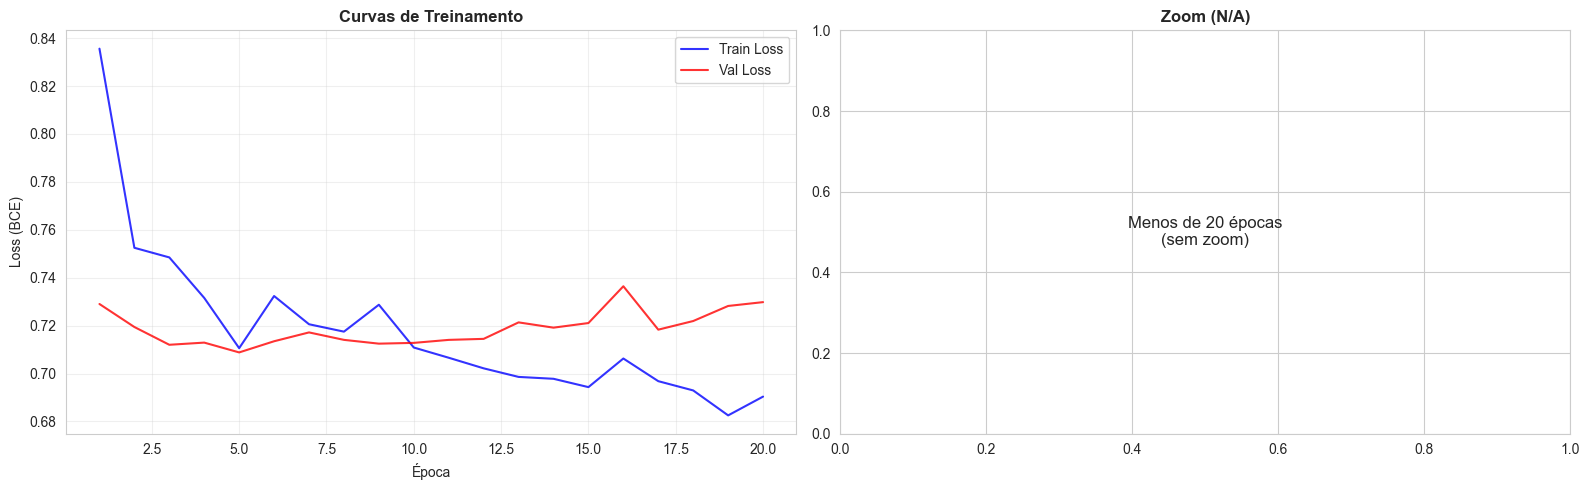

Épocas treinadas: 20
Melhor val_loss: 0.7088 (época 5)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss por época
epochs = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', alpha=0.8)
axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', alpha=0.8)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Curvas de Treinamento', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Zoom nas últimas épocas (se treinou mais de 20)
if len(history['train_loss']) > 20:
    start = max(0, len(history['train_loss']) - 50)
    axes[1].plot(epochs[start:], history['train_loss'][start:], 'b-', label='Train Loss', alpha=0.8)
    axes[1].plot(epochs[start:], history['val_loss'][start:], 'r-', label='Val Loss', alpha=0.8)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss (BCE)')
    axes[1].set_title(f'Últimas {len(epochs)-start} Épocas (Zoom)', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Menos de 20 épocas\n(sem zoom)', 
                ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Zoom (N/A)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Épocas treinadas: {len(history['train_loss'])}")
print(f"Melhor val_loss: {min(history['val_loss']):.4f} (época {history['val_loss'].index(min(history['val_loss']))+1})")

## 9. Validação Cruzada Estratificada (5-Fold)

Requisito obrigatório do Tech Challenge.
Treinar e avaliar com 5 folds diferentes para ter uma estimativa mais robusta.

### obs:
É como fazer load testing com 5 cenários diferentes em vez de um só.
se o modelo funciona bem em todos os 5, temos mais confiança que vai generalizar.

In [13]:
# ── Cross Validation com PyTorch ─────────────────────────────────────────────
# Nota: CV com redes neurais é custoso (treinar 5 modelos completos),
# mas é boa pratica...

print("Iniciando Validação Cruzada Estratificada (5-fold)...")
print("(Isso pode demorar alguns minutos)\n")

# Usar X_train e y_train COMPLETOS (antes do split de validação)
X_train_np = X_train.values
y_train_np = y_train.values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_metrics = {m: [] for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np), 1):
    print(f"  Fold {fold}/5...", end=" ")
    
    # Split
    X_fold_train, X_fold_val = X_train_np[train_idx], X_train_np[val_idx]
    y_fold_train, y_fold_val = y_train_np[train_idx], y_train_np[val_idx]
    
    # Normalizar
    fold_scaler = StandardScaler()
    X_fold_train = fold_scaler.fit_transform(X_fold_train)
    X_fold_val = fold_scaler.transform(X_fold_val)
    
    # Tensors e DataLoaders
    fold_train_ds = TensorDataset(
        torch.FloatTensor(X_fold_train), torch.FloatTensor(y_fold_train)
    )
    fold_val_ds = TensorDataset(
        torch.FloatTensor(X_fold_val), torch.FloatTensor(y_fold_val)
    )
    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # Modelo novo para cada fold
    torch.manual_seed(RANDOM_STATE + fold)
    fold_model = ChurnMLP(
        input_dim=n_features,
        hidden_dims=HIDDEN_DIMS,
        dropout_rate=DROPOUT_RATE
    ).to(device)
    
    fold_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=LEARNING_RATE)
    
    # Treinar (silencioso)
    fold_es = EarlyStopping(patience=PATIENCE)
    for epoch in range(N_EPOCHS):
        fold_model.train()
        for Xb, yb in fold_train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = fold_model(Xb)
            loss = fold_criterion(pred, yb)
            fold_optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=1.0)
            fold_optimizer.step()
        
        fold_model.eval()
        vl = []
        with torch.no_grad():
            for Xb, yb in fold_val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                vl.append(fold_criterion(fold_model(Xb), yb).item())
        
        fold_es(np.mean(vl), fold_model)
        if fold_es.should_stop:
            break
    
    fold_es.restore_best(fold_model)
    
    # Avaliar fold
    fold_model.eval()
    with torch.no_grad():
        logits = fold_model(torch.FloatTensor(X_fold_val).to(device))
        proba = torch.sigmoid(logits).cpu().numpy()
        preds = (proba >= 0.5).astype(int)
    
    cv_metrics['accuracy'].append(accuracy_score(y_fold_val, preds))
    cv_metrics['precision'].append(precision_score(y_fold_val, preds, zero_division=0))
    cv_metrics['recall'].append(recall_score(y_fold_val, preds, zero_division=0))
    cv_metrics['f1'].append(f1_score(y_fold_val, preds, zero_division=0))
    cv_metrics['roc_auc'].append(roc_auc_score(y_fold_val, proba))
    cv_metrics['pr_auc'].append(average_precision_score(y_fold_val, proba))
    
    print(f"F1={cv_metrics['f1'][-1]:.4f}, AUC={cv_metrics['roc_auc'][-1]:.4f}")

print("\n" + "=" * 60)
print("VALIDAÇÃO CRUZADA — MLP (5-fold)")
print("=" * 60)
for metric, values in cv_metrics.items():
    print(f"  {metric:>12s}: {np.mean(values):.4f} (+/- {np.std(values):.4f})")

Iniciando Validação Cruzada Estratificada (5-fold)...
(Isso pode demorar alguns minutos)

  Fold 1/5... F1=0.6320, AUC=0.8411
  Fold 2/5... F1=0.5940, AUC=0.8284
  Fold 3/5... F1=0.6112, AUC=0.8384
  Fold 4/5... F1=0.6287, AUC=0.8606
  Fold 5/5... F1=0.6350, AUC=0.8515

VALIDAÇÃO CRUZADA — MLP (5-fold)
      accuracy: 0.7350 (+/- 0.0122)
     precision: 0.5007 (+/- 0.0146)
        recall: 0.8154 (+/- 0.0285)
            f1: 0.6202 (+/- 0.0155)
       roc_auc: 0.8440 (+/- 0.0111)
        pr_auc: 0.6524 (+/- 0.0156)


## 10. Comparação: MLP vs. Baselines

parte mais importante: comparar a MLP com os baselines da Etapa 1.
precisa re-treinar os baselines para garantir métricas no mesmo split de teste.

### Critério de sucesso (do ML Canvas)
> O modelo MLP deve superar os baselines em pelo menos 2 das 4 métricas definidas.

In [14]:
# ── Retreinar baselines no mesmo split ──────────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# Baseline 1: Dummy (usa dados originais, sem escalar)
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

metrics_dummy = {
    'accuracy': accuracy_score(y_test, y_pred_dummy),
    'precision': precision_score(y_test, y_pred_dummy, zero_division=0),
    'recall': recall_score(y_test, y_pred_dummy, zero_division=0),
    'f1': f1_score(y_test, y_pred_dummy, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_dummy),
    'pr_auc': average_precision_score(y_test, y_proba_dummy),
}

# Baseline 2: Logistic Regression (usa dados escalados)
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_test_lr = scaler_lr.transform(X_test)

lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced')
lr.fit(X_train_lr, y_train)
y_pred_lr = lr.predict(X_test_lr)
y_proba_lr = lr.predict_proba(X_test_lr)[:, 1]

metrics_lr = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'recall': recall_score(y_test, y_pred_lr, zero_division=0),
    'f1': f1_score(y_test, y_pred_lr, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_lr),
    'pr_auc': average_precision_score(y_test, y_proba_lr),
}

print("Baselines re-treinados no mesmo split de teste.")

Baselines re-treinados no mesmo split de teste.


In [15]:
# ── Tabela Comparativa ───────────────────────────────────────────────────────

results = pd.DataFrame([
    {"Modelo": "DummyClassifier (stratified)", **metrics_dummy},
    {"Modelo": "Logistic Regression (balanced)", **metrics_lr},
    {"Modelo": "MLP PyTorch", **metrics_mlp},
])

print("\n" + "=" * 80)
print("TABELA COMPARATIVA — TODOS OS MODELOS")
print("=" * 80)
print(results.to_string(index=False, float_format='{:.4f}'.format))

# Verificar critério de sucesso
main_metrics = ['f1', 'roc_auc', 'pr_auc', 'recall']
wins = sum(1 for m in main_metrics if metrics_mlp[m] > metrics_lr[m])
print(f"\nMLP supera Logistic Regression em {wins}/4 métricas principais.")
if wins >= 2:
    print("CRITÉRIO DE SUCESSO ATINGIDO!")
else:
    print("Critério NÃO atingido. Considere ajustar hiperparâmetros (Seção 12).")


TABELA COMPARATIVA — TODOS OS MODELOS
                        Modelo  accuracy  precision  recall     f1  roc_auc  pr_auc
  DummyClassifier (stratified)    0.6217     0.2891  0.2914 0.2903   0.5163  0.2723
Logistic Regression (balanced)    0.7402     0.5069  0.7861 0.6164   0.8414  0.6306
                   MLP PyTorch    0.7310     0.4959  0.7995 0.6121   0.8385  0.6260

MLP supera Logistic Regression em 1/4 métricas principais.
Critério NÃO atingido. Considere ajustar hiperparâmetros (Seção 12).


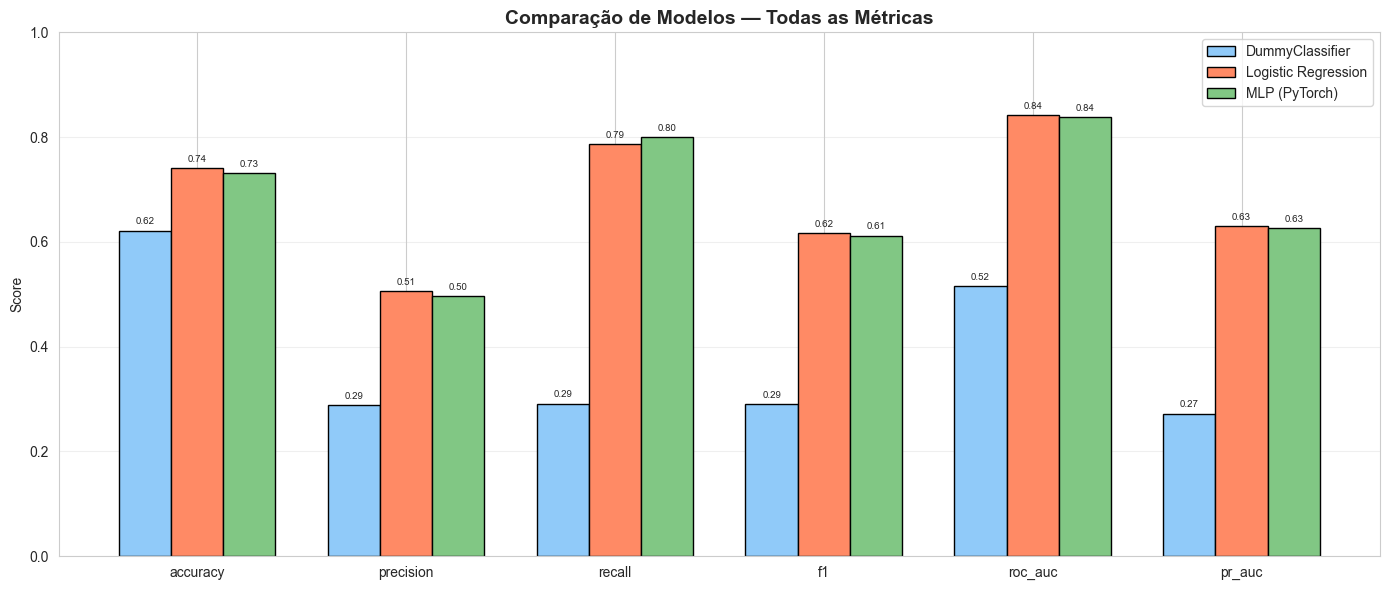

In [16]:
# ── grafico Comparativo ──────────────────────────────────────────────────────
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(metrics_to_plot))
width = 0.25

bars1 = ax.bar(x - width, [metrics_dummy[m] for m in metrics_to_plot], width,
               label='DummyClassifier', color='#90CAF9', edgecolor='black')
bars2 = ax.bar(x, [metrics_lr[m] for m in metrics_to_plot], width,
               label='Logistic Regression', color='#FF8A65', edgecolor='black')
bars3 = ax.bar(x + width, [metrics_mlp[m] for m in metrics_to_plot], width,
               label='MLP (PyTorch)', color='#81C784', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos — Todas as Métricas', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

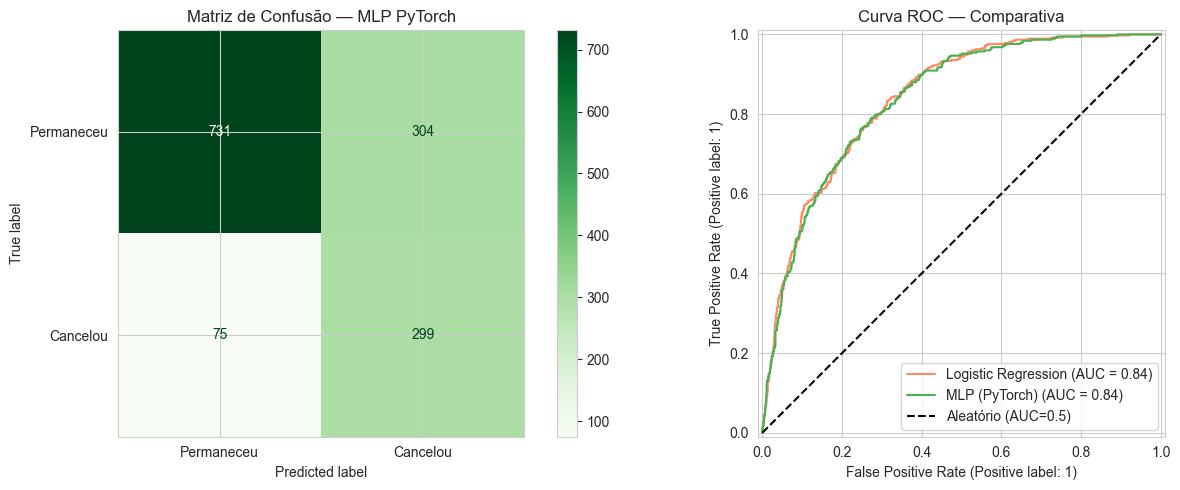

In [17]:
# ── Confusion Matrix e Curva ROC -> MLP ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp, display_labels=['Permaneceu', 'Cancelou'],
    cmap='Greens', ax=axes[0]
)
axes[0].set_title('Matriz de Confusão — MLP PyTorch')

# Curva ROC comparativa
RocCurveDisplay.from_predictions(
    y_test, y_proba_lr, name='Logistic Regression', ax=axes[1], color='#FF8A65'
)
RocCurveDisplay.from_predictions(
    y_test, y_proba_mlp, name='MLP (PyTorch)', ax=axes[1], color='#4CAF50'
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC=0.5)')
axes[1].set_title('Curva ROC — Comparativa')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Análise de Custo  MLP

Mesma analise de custo da Etapa 1, agora com a MLP.

In [18]:
# Análise de custo comparar MLP vs Logistic Regression
avg_monthly = 64.76  # MonthlyCharges médio do dataset
CUSTO_FN = avg_monthly * 12
CUSTO_FP = avg_monthly * 0.20

def analise_custo(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    custo_fn = fn * CUSTO_FN
    custo_fp = fp * CUSTO_FP
    receita_salva = tp * CUSTO_FN
    saldo = receita_salva - custo_fp
    
    print(f"\n{'=' * 50}")
    print(f"{model_name}")
    print(f"{'=' * 50}")
    print(f"  TP (churn detectado):    {tp}")
    print(f"  FN (churn perdido):      {fn}")
    print(f"  FP (alarme falso):       {fp}")
    print(f"  Receita em risco (FN):   ${custo_fn:>10,.2f}")
    print(f"  Custo alarmes (FP):      ${custo_fp:>10,.2f}")
    print(f"  Receita salva (TP):      ${receita_salva:>10,.2f}")
    print(f"  Saldo líquido:           ${saldo:>10,.2f}")
    return saldo

saldo_lr = analise_custo(y_test, y_pred_lr, "Logistic Regression")
saldo_mlp = analise_custo(y_test, y_pred_mlp, "MLP (PyTorch)")

print(f"\n{'=' * 50}")
print(f"Diferença MLP vs LR: ${saldo_mlp - saldo_lr:+,.2f}")
if saldo_mlp > saldo_lr:
    print("MLP gera mais valor de negócio!")
else:
    print("Logistic Regression gera mais valor neste cenário.")


Logistic Regression
  TP (churn detectado):    294
  FN (churn perdido):      80
  FP (alarme falso):       286
  Receita em risco (FN):   $ 62,169.60
  Custo alarmes (FP):      $  3,704.27
  Receita salva (TP):      $228,473.28
  Saldo líquido:           $224,769.01

MLP (PyTorch)
  TP (churn detectado):    299
  FN (churn perdido):      75
  FP (alarme falso):       304
  Receita em risco (FN):   $ 58,284.00
  Custo alarmes (FP):      $  3,937.41
  Receita salva (TP):      $232,358.88
  Saldo líquido:           $228,421.47

Diferença MLP vs LR: $+3,652.46
MLP gera mais valor de negócio!


## 12. Experimentação com Hiperparâmetros (etapa Opcional)

Se a MLP não superou os baselines, podemos tentar ajustar hiperparammetros.
Cada variação é registrada como um novo run no MLflow.

In [19]:
# ── Experimentos adicionais ──────────────────────────────────────────────────
# Descomente e rode para testar diferentes configurações

experiments = [
    {"name": "mlp_wider",    "hidden_dims": [256, 128, 64], "lr": 1e-3, "dropout": 0.3},
    {"name": "mlp_deeper",   "hidden_dims": [128, 64, 32, 16], "lr": 1e-3, "dropout": 0.2},
    {"name": "mlp_low_drop", "hidden_dims": [128, 64, 32], "lr": 1e-3, "dropout": 0.1},
    {"name": "mlp_slow_lr",  "hidden_dims": [128, 64, 32], "lr": 5e-4, "dropout": 0.3},
]

best_f1 = metrics_mlp['f1']
best_name = "mlp_pytorch_v1"

for exp in experiments:
    print(f"\nExperimento: {exp['name']}")
    
    with mlflow.start_run(run_name=exp['name']):
        torch.manual_seed(RANDOM_STATE)
        exp_model = ChurnMLP(
            input_dim=n_features,
            hidden_dims=exp['hidden_dims'],
            dropout_rate=exp['dropout']
        ).to(device)
        
        exp_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=exp['lr'])
        
        # Logar parâmetros
        mlflow.log_param("model_type", "MLP_PyTorch")
        mlflow.log_param("hidden_dims", str(exp['hidden_dims']))
        mlflow.log_param("dropout_rate", exp['dropout'])
        mlflow.log_param("learning_rate", exp['lr'])
        mlflow.log_param("batch_size", BATCH_SIZE)
        mlflow.log_param("experiment_name", exp['name'])
        
        # Treinar
        exp_history = train_model(
            exp_model, train_loader, val_loader,
            exp_criterion, exp_optimizer,
            n_epochs=N_EPOCHS, patience=PATIENCE, device=device
        )
        
        # Avaliar
        exp_model.eval()
        with torch.no_grad():
            logits = exp_model(X_test_tensor.to(device))
            proba = torch.sigmoid(logits).cpu().numpy()
            preds = (proba >= 0.5).astype(int)
        
        exp_metrics = {
            'accuracy': accuracy_score(y_test, preds),
            'precision': precision_score(y_test, preds, zero_division=0),
            'recall': recall_score(y_test, preds, zero_division=0),
            'f1': f1_score(y_test, preds, zero_division=0),
            'roc_auc': roc_auc_score(y_test, proba),
            'pr_auc': average_precision_score(y_test, proba),
        }
        
        for name, value in exp_metrics.items():
            mlflow.log_metric(name, value)
        
        print(f"  F1={exp_metrics['f1']:.4f}, AUC={exp_metrics['roc_auc']:.4f}, "
              f"Recall={exp_metrics['recall']:.4f}")
        
        # Salvar se melhorou
        if exp_metrics['f1'] > best_f1:
            best_f1 = exp_metrics['f1']
            best_name = exp['name']
            torch.save({
                'model_state_dict': exp_model.state_dict(),
                'input_dim': n_features,
                'hidden_dims': exp['hidden_dims'],
                'dropout_rate': exp['dropout'],
                'feature_names': X.columns.tolist(),
                'scaler_mean': scaler.mean_.tolist(),
                'scaler_scale': scaler.scale_.tolist(),
                'metrics': exp_metrics,
            }, MODEL_DIR / "churn_mlp.pt")
            print(f"  >>> Novo melhor modelo! Salvo.")

print(f"\nMelhor modelo: {best_name} (F1={best_f1:.4f})")


Experimento: mlp_wider
  Época   1/200 | Train Loss: 0.7881 | Val Loss: 0.7182 | Patience: 0/15
  Época  10/200 | Train Loss: 0.6963 | Val Loss: 0.7292 | Patience: 2/15
  Época  20/200 | Train Loss: 0.6751 | Val Loss: 0.7446 | Patience: 12/15

  Early Stopping na época 22! Melhor val_loss: 0.7121
  F1=0.6188, AUC=0.8391, Recall=0.8182
  >>> Novo melhor modelo! Salvo.

Experimento: mlp_deeper
  Época   1/200 | Train Loss: 0.9028 | Val Loss: 0.7668 | Patience: 0/15
  Época  10/200 | Train Loss: 0.7129 | Val Loss: 0.7242 | Patience: 4/15
  Época  20/200 | Train Loss: 0.6709 | Val Loss: 0.7439 | Patience: 14/15

  Early Stopping na época 20! Melhor val_loss: 0.7117
  F1=0.6184, AUC=0.8400, Recall=0.8342

Experimento: mlp_low_drop
  Época   1/200 | Train Loss: 0.7882 | Val Loss: 0.7211 | Patience: 0/15
  Época  10/200 | Train Loss: 0.6662 | Val Loss: 0.7250 | Patience: 6/15

  Early Stopping na época 18! Melhor val_loss: 0.7157
  F1=0.6113, AUC=0.8358, Recall=0.7674

Experimento: mlp_slow_

## 13. Conclusões da Etapa 2

### Resumo dos Resultados

In [20]:
# ── Resumo Final ─────────────────────────────────────────────────────────────
print("=" * 70)
print("RESUMO DA ETAPA 2 MLP com PyTorch")
print("=" * 70)

print("\n1. ARQUITETURA")
print(f"   - Tipo: MLP (Multi-Layer Perceptron)")
print(f"   - Camadas: {HIDDEN_DIMS}")
print(f"   - Ativação: ReLU + BatchNorm + Dropout({DROPOUT_RATE})")
print(f"   - Loss: BCEWithLogitsLoss (pos_weight={pos_weight.item():.2f})")
print(f"   - Optimizer: Adam (lr={LEARNING_RATE})")

print(f"\n2. TREINAMENTO")
print(f"   - epocas treinadas: {len(history['train_loss'])}")
print(f"   - Early Stopping: patience={PATIENCE}")
print(f"   - Batch size: {BATCH_SIZE}")

print(f"\n3. MÉTRICAS (Teste)")
for name, value in metrics_mlp.items():
    marker = " <<<" if name in main_metrics else ""
    print(f"   - {name:>12s}: {value:.4f}{marker}")

print(f"\n4. CROSS-VALIDATION (5-fold)")
for metric, values in cv_metrics.items():
    print(f"   - {metric:>12s}: {np.mean(values):.4f} (+/- {np.std(values):.4f})")

print(f"\n5. ARTEFATOS")
print(f"   - Modelo: models/churn_mlp.pt")
print(f"   - Scaler: models/scaler.joblib")
print(f"   - MLflow runs: mlruns/")

print(f"\n6. PRÓXIMOS PASSOS (Etapa 3)")
print(f"   - Refatorar código em módulos (src/)")
print(f"   - ntegrar modelo na FastAPI (/predict)")
print(f"   - testes automatizados")
print(f"   - Configurar linting (ruff) e CI")

RESUMO DA ETAPA 2 MLP com PyTorch

1. ARQUITETURA
   - Tipo: MLP (Multi-Layer Perceptron)
   - Camadas: [128, 64, 32]
   - Ativação: ReLU + BatchNorm + Dropout(0.3)
   - Loss: BCEWithLogitsLoss (pos_weight=2.77)
   - Optimizer: Adam (lr=0.001)

2. TREINAMENTO
   - epocas treinadas: 20
   - Early Stopping: patience=15
   - Batch size: 64

3. MÉTRICAS (Teste)
   -     accuracy: 0.7310
   -    precision: 0.4959
   -       recall: 0.7995 <<<
   -           f1: 0.6121 <<<
   -      roc_auc: 0.8385 <<<
   -       pr_auc: 0.6260 <<<

4. CROSS-VALIDATION (5-fold)
   -     accuracy: 0.7350 (+/- 0.0122)
   -    precision: 0.5007 (+/- 0.0146)
   -       recall: 0.8154 (+/- 0.0285)
   -           f1: 0.6202 (+/- 0.0155)
   -      roc_auc: 0.8440 (+/- 0.0111)
   -       pr_auc: 0.6524 (+/- 0.0156)

5. ARTEFATOS
   - Modelo: models/churn_mlp.pt
   - Scaler: models/scaler.joblib
   - MLflow runs: mlruns/

6. PRÓXIMOS PASSOS (Etapa 3)
   - Refatorar código em módulos (src/)
   - ntegrar modelo na Fast

In [21]:
print("Etapa 2 concluída!")
print("\nPara visualizar TODOS os experimentos no MLflow:")
print("  cd ml-engineering-churn-prediction")
print("  mlflow ui --backend-store-uri mlruns")
print("  Abra: http://localhost:5000")

Etapa 2 concluída!

Para visualizar TODOS os experimentos no MLflow:
  cd ml-engineering-churn-prediction
  mlflow ui --backend-store-uri mlruns
  Abra: http://localhost:5000
